### Load the `HTRU_2.csv` dataset


- Confirming the data loaded correctly before anything else
- HTRU2 has 8 feature columns come in two  groups of 4 (mean/std/kurtosis/skewness):
one set describing the integrated pulse profile (`_ip`), one describing the DM-SNR curve
(`_dm`).
- `class` is the binary target (1 = pulsar, 0 = non-pulsar).

In [1]:
import pandas as pd

cols = ['mean_ip','std_ip','kurt_ip','skew_ip',
        'mean_dm','std_dm','kurt_dm','skew_dm','class']

df = pd.read_csv('../data/HTRU_2.csv', header=None, names=cols)

print(f"Shape: {df.shape}")                     
print(f"Class distribution:\n{df['class'].value_counts()}")   
print(f"Null values: {df.isnull().sum().sum()}")      
df.head()

Shape: (17898, 9)
Class distribution:
class
0    16259
1     1639
Name: count, dtype: int64
Null values: 0


,mean_ip,std_ip,kurt_ip,skew_ip,mean_dm,std_dm,kurt_dm,skew_dm,class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


### Train/test split

Splits the data 80/20 into train and test sets, stratified on `class`, before any plotting or analysis.
`df_train` is then rebuilt from the training rows only, purely so the EDA cells below have something to plot.
The test set's purpose is to simulate genuinely unseen data. To ensure the test set remains genuinely unseen during model development, the data is split before any plotting or analysis.

- `stratify=y` keeps the ~9:1 non-pulsar:pulsar ratio consistent in both splits

In [2]:
from sklearn.model_selection import train_test_split
import numpy as np

X = df.drop('class', axis=1)
y = df['class']

# Stratify to preserve the 9/1 ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} samples, "
      f"Pulsars: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} samples, "
      f"Pulsars: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

# Recombine the training rows only (purely for the exploratory plots below)
# X_test / y_test are not touched again till the final evaluation section
df_train = X_train.copy()
df_train['class'] = y_train

Train: 14318 samples, Pulsars: 1311 (9.2%)
Test:  3580 samples, Pulsars: 328 (9.2%)


### Class distribution plot

Bar chart of pulsar vs non-pulsar counts in the training set.
- To make the class imbalance immediately visible. The approximate 9:1 non-pulsar to pulsar ratio is the core challenge addressed throughout this notebook. This motivates techniques such as SMOTE, class_weight='balanced' and the use of F1 score over accuracy as the primary evaluation metric.

- The plot is generated using df_train only, keeping it consistent with the decision to perform EDA exclusively on the training split.

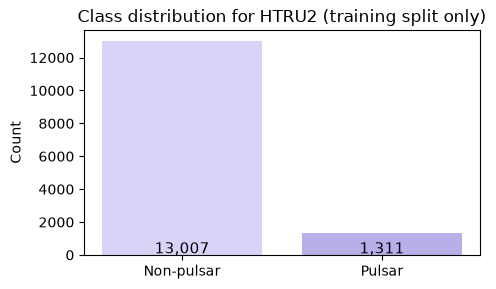

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class distribution (non-pulsar vs pulsar)
fig, ax = plt.subplots(figsize=(5,3))
counts = df_train['class'].value_counts()
# the counts are determined by the last column in which 0 represents non-pulsar & 1 represents pulsar
ax.bar(['Non-pulsar','Pulsar'], counts.values, color=['#D9D4F7','#B8AFE8'])
for i, v in enumerate(counts.values):
    ax.text(i, 100, f'{v:,}', ha='center', fontsize=11)
ax.set_title('Class distribution for HTRU2 (training split only)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/class_distribution.png')
plt.show()

### Feature distributions by class

Histograms for all 8 features, split by class and overlaid for comparison.

- This shows whether pulsars and non-pulsars are visibly separable on any single feature

- useful sanity check before trusting a model's results. If pulsar and non-pulsar
histograms overlapped almost entirely on every feature, that would be a warning sign that that the features available aren't very informative.

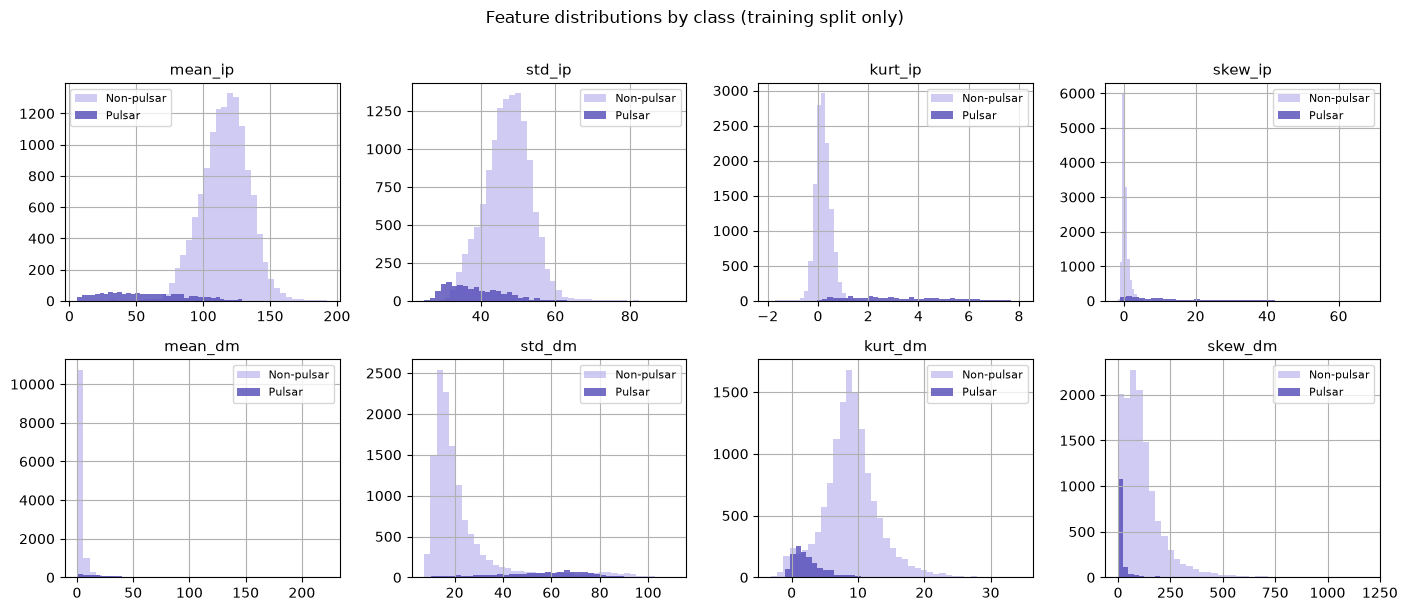

In [4]:
# Feature distributions by class, training split only (non-pulsar vs pulsar)
features = ['mean_ip','std_ip','kurt_ip','skew_ip','mean_dm','std_dm','kurt_dm','skew_dm']
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()
for i, feat in enumerate(features):
    df_train[df_train['class']==0][feat].hist(ax=axes[i], alpha=0.6, bins=40, color='#AFA9EC', label='Non-pulsar')
    df_train[df_train['class']==1][feat].hist(ax=axes[i], alpha=0.8, bins=40, color='#534AB7', label='Pulsar')
    axes[i].set_title(feat, fontsize=11)
    axes[i].legend(fontsize=8)
plt.suptitle('Feature distributions by class (training split only)', y=1.01)
plt.tight_layout()
plt.savefig('../reports/feature_distributions.png')
plt.show()

### Feature correlation matrix

A heatmap of pairwise correlations between all 8 features.

Highly correlated features can mean redundant information (may be worth noting to understand the structure of the dataset) 
- note: not used to drop any features in this notebook*

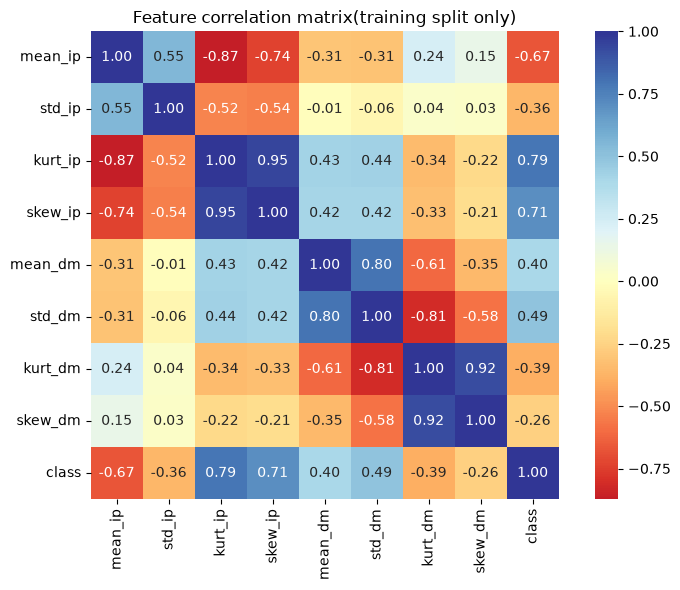

In [5]:
# Feature correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(df_train.corr(), annot=True, fmt='.2f',
            cmap='RdYlBu', center=0, square=True)
plt.title('Feature correlation matrix(training split only)')
plt.tight_layout()
plt.savefig('../reports/correlation_matrix.png')
plt.show()

### Build the modeling pipeline

3 step `imblearn` pipeline: 
- SMOTE (oversample the minority/pulsar class) → `StandardScaler` → `RandomForestClassifier` with `class_weight='balanced'`

To create a modelling workflow that addresses class imbalance while keeping preprocessing consistent across models. Although Random Forests do not strictly require feature scaling, StandardScaler is included for consistency because other models evaluated later (Logistic Regression) do benefit from scaling.

`SMOTE` and `class_weight='balanced'` represent two different approaches to handling the approximate 9:1 class imbalance. Both are applied initially, with their individual contributions tested later in the ablation analysis.

note: SMOTE is only be applied to training data and never to validation or test data

In [6]:
from imblearn.pipeline import Pipeline   
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('smote',  SMOTE(random_state=42)),       # oversample the minority class(pulsars) to match the majority class (non-pulsars)
    ('scaler', StandardScaler()),              # scale after SMOTE
    ('clf',    RandomForestClassifier(
                   n_estimators=200,
                   class_weight='balanced',
                   random_state=42,
                   n_jobs=-1))
])
print(pipeline)

Pipeline(steps=[('smote', SMOTE(random_state=42)), ('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])


### Compare multiple model families via cross-validation
Running a 5 fold stratified CV for four candidates (`DummyClassifier` baseline,
Logistic Regression, Random Forest, XGBoost)
- Scoring each: F1, ROC-AUC, precision, recall

To identify which model family is most worth tuning further using robust cross-validated performance rather than a single train/test split, reducing sensitivity to how the data happens to be divided.

Note: Dummy baseline (`strategy='most_frequent'`: which always predicts non-pulsar) is included specifically to prove that high accuracy alone is meaningless on this imbalanced dataset.

In [7]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['f1','roc_auc','precision','recall'] 

models = {
    'Dummy': DummyClassifier(strategy='most_frequent'),
    'Logistic': Pipeline([('smote',SMOTE(random_state=42)), ('scaler',StandardScaler()),
                          ('clf',LogisticRegression(class_weight='balanced',max_iter=1000))]),
    'RF': Pipeline([('smote',SMOTE(random_state=42)), ('scaler',StandardScaler()),
                    ('clf',RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=42))]),
    'XGBoost': Pipeline([('smote',SMOTE(random_state=42)), ('scaler',StandardScaler()),
                         ('clf',xgb.XGBClassifier(n_estimators=200, scale_pos_weight=9.9, random_state=42, eval_metric='logloss'))]),
}

results = {}
for name, model in models.items():
    print(f"Training {name}:")
    scores = cross_validate(model, X_train, y_train, cv=cv,
                            scoring=scoring, n_jobs=-1)
    results[name] = {k: scores[f'test_{k}'].mean() for k in scoring}
    print(f"  F1={results[name]['f1']:.3f}  AUC={results[name]['roc_auc']:.3f}")

Training Dummy:
  F1=0.000  AUC=0.500
Training Logistic:
  F1=0.846  AUC=0.977
Training RF:
  F1=0.867  AUC=0.976
Training XGBoost:
  F1=0.809  AUC=0.975


### Print the CV comparison results
Among the Models,both Random Forest and XGBoost are chosen to continue as  Random Forest offers the best overall balance with the highest F1, while XGBoost demonstrates higher recall. Logistic Regression is not selected despite being only 0.001 lower in recall than XGBoost (0.907 vs 0.908) and outperforming it in every other metric (precision and F1). It is so as Logistic Regression (linear model) has limited capacity to capture the complex non-linear relationships and feature interactions that tree-based models can learn. Additionally, while Logistic Regression's recall is near its practical ceiling at default settings, XGBoost's lower precision and F1 indicate significant room for improvement through hyperparameter tuning.

In [8]:
import pandas as pd
res_df = pd.DataFrame(results).T.round(3)
print(res_df.to_string())

             f1  roc_auc  precision  recall
Dummy     0.000    0.500      0.000   0.000
Logistic  0.846    0.977      0.793   0.907
RF        0.867    0.976      0.841   0.896
XGBoost   0.809    0.975      0.731   0.908


### Learning curve

Retrains the pipeline on increasing fractions of the training data (10% → 100%) and tracks both training F1 and cross-validated F1 at each size.

To assess overfitting and determine whether model performance is limited by data availability. The cross-validation comparison above shows relative model performance, but it does not reveal how performance changes as more data is introduced. A widening gap between training and validation F1 suggests overfitting, while a validation score that is still improving at 100% of the available data indicates that additional data would likely improve performance further.

he XGBoost learning curve shows more fluctuation and a larger gap, likely due to its higher model complexity and sensitivity to hyperparameters. Both curves suggest that with additional data, performance might improve, but with the current dataset, Random Forest is more robust.



Random Forest
Train F1: 1.000, Val F1: 0.866, Gap: 0.134

XGBoost
Train F1: 0.993, Val F1: 0.805, Gap: 0.189


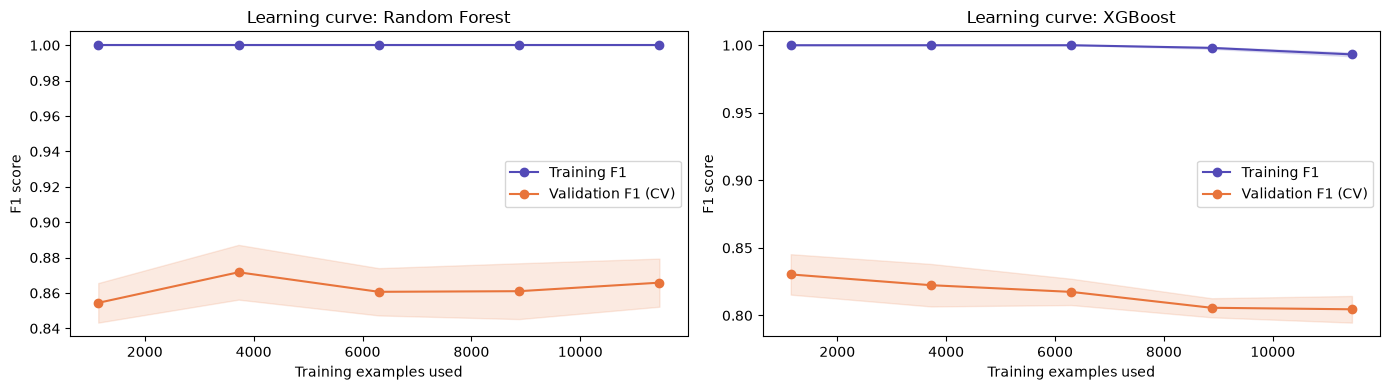

In [9]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (name, model) in zip(axes, {
    'Random Forest': models['RF'],
    'XGBoost':       models['XGBoost'],
}.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        cv=cv, scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1, random_state=42
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='#534AB7', label='Training F1')
    ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='#534AB7')
    ax.plot(train_sizes, val_mean,   'o-', color='#E8743B', label='Validation F1 (CV)')
    ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color='#E8743B')
    ax.set_title(f'Learning curve: {name}')
    ax.set_xlabel('Training examples used')
    ax.set_ylabel('F1 score')
    ax.legend()
    
    gap = train_mean[-1] - val_mean[-1]

    print(f"\n{name}")
    print(f"Train F1: {train_mean[-1]:.3f}, Val F1: {val_mean[-1]:.3f}, Gap: {gap:.3f}")
    
plt.tight_layout()
plt.savefig('../reports/learning_curves.png')
plt.show()

### Imbalance-handling ablation: SMOTE vs class_weight vs both

Re-runs cross-validation on three pipeline variants: SMOTE + `class_weight`
combined (original assumption), SMOTE alone and `class_weight` alone with no SMOTE.

The original pipeline applied both corrections for class imbalance without
testing whether that combination was actually the best choice, or whether one alone (or
neither) would do better. SMOTE can sometimes introduce synthetic points that are too close to existing minority samples, increasing the risk of overfitting, particularly for tree-based models. This ablation explicitly evaluates that trade-off rather than assuming the combined approach is optimal.

SMOTE-only was choosen to continue as it produces higher recall, which is the primary metricin this case. ALthough SMOTE-only performs almost identically to the combined SMOTE + class_weight approach,  it also performs slightly better across the other metrics.

In [10]:
variants = {
    'SMOTE + balanced (current)': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)),
    ]),
    'SMOTE only': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ]),
    'class_weight only (no SMOTE)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)),
    ]),
}

ablation_results = {}
for name, mdl in variants.items():
    scores = cross_validate(mdl, X_train, y_train, cv=cv, scoring=['f1','precision','recall','roc_auc'], n_jobs=-1)
    ablation_results[name] = {k: scores[f'test_{k}'].mean() for k in ['f1','precision','recall','roc_auc']}

ablation_df = pd.DataFrame(ablation_results).T.round(3)
print(ablation_df.to_string())


                                 f1  precision  recall  roc_auc
SMOTE + balanced (current)    0.867      0.841   0.896    0.976
SMOTE only                    0.868      0.843   0.896    0.976
class_weight only (no SMOTE)  0.883      0.890   0.877    0.973


- Base pipelines used for RF and XGBoost hyperparameter tuning below
- These match the SMOTE-only variant (ablation winner on recall & f1).
Note: XGBoost initial comparison used scale_pos_weight=9.9 as a starting baseline
- here it to default '1', tuning grid later searches it from scratch

In [11]:

rf_pipeline_ablation = Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('scaler', StandardScaler()),
            ('clf', RandomForestClassifier(n_estimators=200,
                                           random_state=42, n_jobs=-1)),
        ])
xgb_pipeline_ablation = Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('scaler', StandardScaler()),
            ('clf', xgb.XGBClassifier(n_estimators=200,
                                      random_state=42, eval_metric='logloss')),
        ])


print("rf_pipeline_ablation:", list(rf_pipeline_ablation.named_steps.keys()))
print("xgb_pipeline_ablation:", list(xgb_pipeline_ablation.named_steps.keys()))

rf_pipeline_ablation: ['smote', 'scaler', 'clf']
xgb_pipeline_ablation: ['smote', 'scaler', 'clf']


### Models Hyperparameter tuning (RandomizedSearchCV)

Searches over key hyperparameters for both Random Forest and XGBoost, using 35 random combinations evaluated via 5-fold cross-validation. Models are tuned twice: once optimising F1 and once optimising recall, to compare how each metric influences the precision-recall tradeoff.

To improve model performance beyond default hyperparameters, which are rarely optimal. Currently RandomizedSearchCV is used instead of GridSearchCV because it explores a large hyperparameter space more efficient.

In [12]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_rf= {
    'clf__n_estimators': [100, 200, 400],
    'clf__max_depth':[None, 10, 20, 30],
    'clf__min_samples_split': [2, 5, 10],
    'clf__max_features':['sqrt', 'log2'],
}
 
search_rf_f1= RandomizedSearchCV(
    rf_pipeline_ablation, param_grid_rf,
    n_iter=35, scoring='f1',
    cv=cv, n_jobs=-1, random_state=42, verbose=1
)

search_rf_recall= RandomizedSearchCV(
    rf_pipeline_ablation, param_grid_rf,
    n_iter=35, scoring='recall',
    cv=cv, n_jobs=-1, random_state=42, verbose=1
)
search_rf_f1.fit(X_train, y_train)
best_rf_f1 = search_rf_f1.best_estimator_
print("Best CV F1 (RF):", round(search_rf_f1.best_score_, 3))
print("Best params:", search_rf_f1.best_params_)

search_rf_recall.fit(X_train, y_train)
best_rf_recall = search_rf_recall .best_estimator_
print("Best CV recall (RF):", round(search_rf_recall.best_score_, 3))
print("Best params:", search_rf_recall.best_params_)


scoring = ['f1', 'precision', 'recall', 'roc_auc']

rf_candidates = {
    'RF tuned for F1': best_rf_f1,
    'RF tuned for Recall': best_rf_recall
}

rf_results = {}

for name, model in rf_candidates.items():
    scores = cross_validate(model, X_train, y_train, cv=cv,
                            scoring=scoring, n_jobs=-1
    )

    rf_results[name] = {
        metric: scores[f'test_{metric}'].mean()
        for metric in scoring
    }

rf_results_df = pd.DataFrame(rf_results).T.round(3)
print(rf_results_df.to_string())

Fitting 5 folds for each of 35 candidates, totalling 175 fits
Best CV F1 (RF): 0.869
Best params: {'clf__n_estimators': 200, 'clf__min_samples_split': 5, 'clf__max_features': 'sqrt', 'clf__max_depth': None}
Fitting 5 folds for each of 35 candidates, totalling 175 fits
Best CV recall (RF): 0.901
Best params: {'clf__n_estimators': 400, 'clf__min_samples_split': 10, 'clf__max_features': 'log2', 'clf__max_depth': 10}
                        f1  precision  recall  roc_auc
RF tuned for F1      0.869      0.843   0.898    0.976
RF tuned for Recall  0.861      0.826   0.901    0.978


In [13]:
param_grid_xgb = {
    'clf__n_estimators':     [100, 200, 400],
    'clf__max_depth':        [3, 5, 7, 9],
    'clf__learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'clf__subsample':        [0.7, 0.8, 1.0],
    'clf__colsample_bytree': [0.7, 0.8, 1.0],
    'clf__scale_pos_weight': [1, float(y_train.value_counts()[0] / y_train.value_counts()[1])],
}

search_xgb_recall = RandomizedSearchCV(
    xgb_pipeline_ablation, param_grid_xgb,
    n_iter=35, scoring='recall',
    cv=cv, n_jobs=-1, random_state=42, verbose=1
)

search_xgb_f1 = RandomizedSearchCV(
    xgb_pipeline_ablation, param_grid_xgb,
    n_iter=35, scoring='f1',
    cv=cv, n_jobs=-1, random_state=42, verbose=1
)

search_xgb_f1.fit(X_train, y_train)
print("Best CV F1 (XGBoost):", round(search_xgb_f1.best_score_, 3))
print("Best params:", search_xgb_f1.best_params_)
best_xgb_f1 = search_xgb_f1.best_estimator_

search_xgb_recall.fit(X_train, y_train)
print("Best CV recall (XGBoost):", round(search_xgb_recall.best_score_, 3))
print("Best params:", search_xgb_recall.best_params_)
best_xgb_recall = search_xgb_recall.best_estimator_

xgb_candidates = {
    'XGB tuned for F1': best_xgb_f1,
    'XGB tuned for Recall': best_xgb_recall
}

xgb_results = {}

for name, model in xgb_candidates.items():
    scores = cross_validate(model, X_train, y_train, cv=cv,
                            scoring=scoring, n_jobs=-1
    )

    xgb_results[name] = {
        metric: scores[f'test_{metric}'].mean()
        for metric in scoring
    }

xgb_results_df = pd.DataFrame(xgb_results).T.round(3)
print(xgb_results_df.to_string())

Fitting 5 folds for each of 35 candidates, totalling 175 fits
Best CV F1 (XGBoost): 0.855
Best params: {'clf__subsample': 0.8, 'clf__scale_pos_weight': 1, 'clf__n_estimators': 400, 'clf__max_depth': 9, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.7}
Fitting 5 folds for each of 35 candidates, totalling 175 fits
Best CV recall (XGBoost): 0.99
Best params: {'clf__subsample': 1.0, 'clf__scale_pos_weight': 9.921434019832189, 'clf__n_estimators': 100, 'clf__max_depth': 3, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 1.0}
                         f1  precision  recall  roc_auc
XGB tuned for F1      0.855      0.814   0.902    0.979
XGB tuned for Recall  0.285      0.167   0.990    0.976


### Selected models for comparison
Based on the results, the following models are carried forward for final evaluation:
Random Forest tuned for best recall:a chieves CV recall of 0.901 with balanced precision of 0.826
XGBoost tuned for best F1: achieves CV F1 of 0.855 with recall of 0.902 and precision of 0.814

Despite recall being the primary metric, XGBoost F1-tuned variant is chosen over its recall-tuned as it over sacrifices precision (0.167) and f1 (0.285) to achieve near perfect recall, making it impractical for deployment.

Both selected models are evaluated on the held-out test set to provide an unbiased comparison and determine the final winner.

Given that recall being the primary metric and F1 being the secondary metric for balancing precision, XGBoost is selected as the final model. It achieves slightly higher recall and F1 on the test set. While RF has a marginally higher ROC-AUC, the recall and F1 improvements in XGBoost are more meaningful for our objective of detecting pulsars. 

In [14]:
from sklearn.metrics import classification_report, recall_score, precision_score, f1_score, roc_auc_score
best_rf  = best_rf_recall
best_xgb = best_xgb_f1

best_rf.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)

y_pred_rf  = best_rf.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test)

y_proba_rf  = best_rf.predict_proba(X_test)[:, 1]
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("Tuned RF (recall-optimised)")
print(classification_report(y_test, y_pred_rf, target_names=['Non-pulsar','Pulsar']))

print("Tuned XGBoost (F1-optimised)")
print(classification_report(y_test, y_pred_xgb, target_names=['Non-pulsar','Pulsar']))

print("Side-by-side summary (pulsar class)")
print(f"{'Model':<20} {'Recall':>8} {'Precision':>10} {'F1':>8} {'ROC-AUC':>9}")
print(f"{'Tuned RF':<20} {recall_score(y_test,y_pred_rf):>8.3f} {precision_score(y_test,y_pred_rf):>10.3f} {f1_score(y_test,y_pred_rf):>8.3f} {roc_auc_score(y_test, y_proba_rf):>9.3f}")
print(f"{'Tuned XGBoost':<20} {recall_score(y_test,y_pred_xgb):>8.3f} {precision_score(y_test,y_pred_xgb):>10.3f} {f1_score(y_test,y_pred_xgb):>8.3f} {roc_auc_score(y_test, y_proba_xgb):>9.3f}")

Tuned RF (recall-optimised)
              precision    recall  f1-score   support

  Non-pulsar       0.99      0.98      0.98      3252
      Pulsar       0.81      0.90      0.85       328

    accuracy                           0.97      3580
   macro avg       0.90      0.94      0.92      3580
weighted avg       0.97      0.97      0.97      3580

Tuned XGBoost (F1-optimised)
              precision    recall  f1-score   support

  Non-pulsar       0.99      0.98      0.98      3252
      Pulsar       0.81      0.91      0.85       328

    accuracy                           0.97      3580
   macro avg       0.90      0.94      0.92      3580
weighted avg       0.97      0.97      0.97      3580

Side-by-side summary (pulsar class)
Model                  Recall  Precision       F1   ROC-AUC
Tuned RF                0.899      0.806    0.850     0.977
Tuned XGBoost           0.905      0.809    0.855     0.977


XGBoost selected: higher recall and F1 (acceptable precision for deployment)

In [15]:
best_model = best_xgb

### Nested cross-validation sanity check

A more rigorous validation scheme is performed to obtain a less biased estimate of model performance. For each of 3 outer folds, an inner RandomizedSearchCV is run on the training portion only to tune hyperparameters, and the resulting best model is evaluated on the held-out outer-fold validation set. This separates hyperparameter selection from performance estimation, preventing the optimistic bias that can occur when the same folds are used for both tuning and evaluation.

The nested CV F1 (0.848) is close to the simple CV F1 (0.869) from the hyperparameter search. The slightly lower value reflects the more conservative nature of nested CV. The small standard deviation (0.006) shows stable performance across different data splits.

Hyperparameter choices are consistent across folds—400 estimators is selected every time, with max_depth of 5-7 and learning_rate of 0.05-0.1. This consistency confirms the optimization is robust and the model generalizes well to unseen data
The nested CV estimate of 0.848 is close to the simple CV F1 of 0.869 from the earlier hyperparameter search, with the slightly lower value reflecting the more conservative nature of nested CV. The small standard deviation (±0.006) indicates that the model's performance is stable across different data splits. The consistent hyperparameter choices (tending toward 400 estimators and depth 5-7) suggest robust optimization. This nested validation confirms that the simple CV estimates were not substantially optimistic and that the model generalizes well to completely unseen data.

In [16]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, classification_report

param_grid_small = {
        'clf__n_estimators':  [100, 200, 400],
        'clf__max_depth':     [3, 5, 7],
        'clf__learning_rate': [0.05, 0.1, 0.2],
    }

outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=2)

nested_scores = []
for fold_i, (tr_idx, val_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    inner_search = RandomizedSearchCV(
        best_model, param_grid_small,
        n_iter=8, scoring='f1', cv=inner_cv, n_jobs=-1, random_state=0
    )
    inner_search.fit(X_tr, y_tr)
    fold_f1 = f1_score(y_val, inner_search.best_estimator_.predict(X_val))
    nested_scores.append(fold_f1)
    print(f"Outer fold {fold_i}: F1 = {fold_f1:.3f} ,(best params this fold: {inner_search.best_params_})")

nested_scores = np.array(nested_scores)
print(f"\nNested CV F1: {nested_scores.mean():.3f} +/- {nested_scores.std():.3f}")

print(f"\nSimple CV scores from tuning searches (for comparison):")
print(f"  RF (F1: {search_rf_f1.best_score_:.3f} , Recall: {search_rf_recall.best_score_:.3f})")
print(f"  XGBoost (F1: {search_xgb_f1.best_score_:.3f} , Recall: {search_xgb_recall.best_score_:.3f})")
print(f"\nNested CV ({nested_scores.mean():.3f}) vs simple CV XGB F1 ({search_xgb_f1.best_score_:.3f}): gap = {search_xgb_f1.best_score_ - nested_scores.mean():.3f}")

Outer fold 1: F1 = 0.850 ,(best params this fold: {'clf__n_estimators': 400, 'clf__max_depth': 7, 'clf__learning_rate': 0.1})
Outer fold 2: F1 = 0.855 ,(best params this fold: {'clf__n_estimators': 400, 'clf__max_depth': 7, 'clf__learning_rate': 0.1})
Outer fold 3: F1 = 0.840 ,(best params this fold: {'clf__n_estimators': 400, 'clf__max_depth': 5, 'clf__learning_rate': 0.05})

Nested CV F1: 0.848 +/- 0.006

Simple CV scores from tuning searches (for comparison):
  RF (F1: 0.869 , Recall: 0.901)
  XGBoost (F1: 0.855 , Recall: 0.990)

Nested CV (0.848) vs simple CV XGB F1 (0.855): gap = 0.007


### Final test-set evaluation

Fits the tuned XGBoost model on the full training set, then evaluates it on the test set (final performance estimate) and the training set (for diagnostic comparison only).

- Reports classification metrics, ROC-AUC, PR-AUC, train–test F1 gap.

To provide a single, unbiased estimate of real-world performance using the held-out test set. All model selection and tuning is done via cross-validation in earlier steps to avoid leakage. The training set comparison is included solely to check for overfitting.

The model achieves strong test performance with excellent recall (91% of pulsars detected) and good precision (81% of pulsar predictions are correct). The ROC-AUC of 0.977 and PR-AUC of 0.929 confirm robust class separation and strong minority-class performance. The 0.073 F1 gap between training and test indicates some overfitting, which is expected given the class imbalance and model complexity, but the gap is acceptable and the test performance remains strong. The model meets our recall-first objective while maintaining practical precision levels, making it suitable for deployment where detecting pulsars is the priority.


In [17]:
from sklearn.metrics import (classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay, average_precision_score)
import matplotlib.pyplot as plt

# Fit best model on full training set, then predict on test
best_model.fit(X_train, y_train)
# Test-set predictions
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:,1]

# Training set predictions (check for overfitting, not for actual model performance)
y_train_pred  = best_model.predict(X_train)
y_train_proba = best_model.predict_proba(X_train)[:,1]

print(" Classification Report (TEST set)")
print(classification_report(y_test, y_pred,target_names=['Non-pulsar','Pulsar']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_proba):.4f}")

print("\n Classification Report (TRAINING set, for comparison only)")
print(classification_report(y_train, y_train_pred, target_names=['Non-pulsar','Pulsar']))

train_f1 = classification_report(y_train, y_train_pred, target_names=['Non-pulsar','Pulsar'], output_dict=True)['Pulsar']['f1-score']
test_f1  = classification_report(y_test, y_pred, target_names=['Non-pulsar','Pulsar'], output_dict=True)['Pulsar']['f1-score']
print(f"\nPulsar-class F1 — train: {train_f1:.3f}, test: {test_f1:.3f}, gap: {train_f1-test_f1:.3f}")

 Classification Report (TEST set)
              precision    recall  f1-score   support

  Non-pulsar       0.99      0.98      0.98      3252
      Pulsar       0.81      0.91      0.85       328

    accuracy                           0.97      3580
   macro avg       0.90      0.94      0.92      3580
weighted avg       0.97      0.97      0.97      3580

ROC-AUC: 0.9766
PR-AUC: 0.9288

 Classification Report (TRAINING set, for comparison only)
              precision    recall  f1-score   support

  Non-pulsar       1.00      0.99      0.99     13007
      Pulsar       0.88      0.98      0.93      1311

    accuracy                           0.99     14318
   macro avg       0.94      0.98      0.96     14318
weighted avg       0.99      0.99      0.99     14318


Pulsar-class F1 — train: 0.927, test: 0.855, gap: 0.073


### Confusion matrix, ROC curve, precision-recall curve

Three plots visualizing the same test-set predictions from a different angle each: 
- where errors land (confusion matrix)
- the tradeoff between true and false positive rates at every threshold (ROC)
- the tradeoff between precision and recall at every threshold (PR curve)

To move beyond a single aggregate metric like F1 and understand the type of errors the model makes. 
The confusion matrix reveals whether mistakes are dominated by false negatives (missed pulsars) or false positives (false alarms), which have different practical implications. 
The ROC curve shows how well the model separates classes across all thresholds, while the precision–recall curve is especially important in this imbalanced setting, where ROC can appear overly optimistic even when performance on the minority class is weaker.

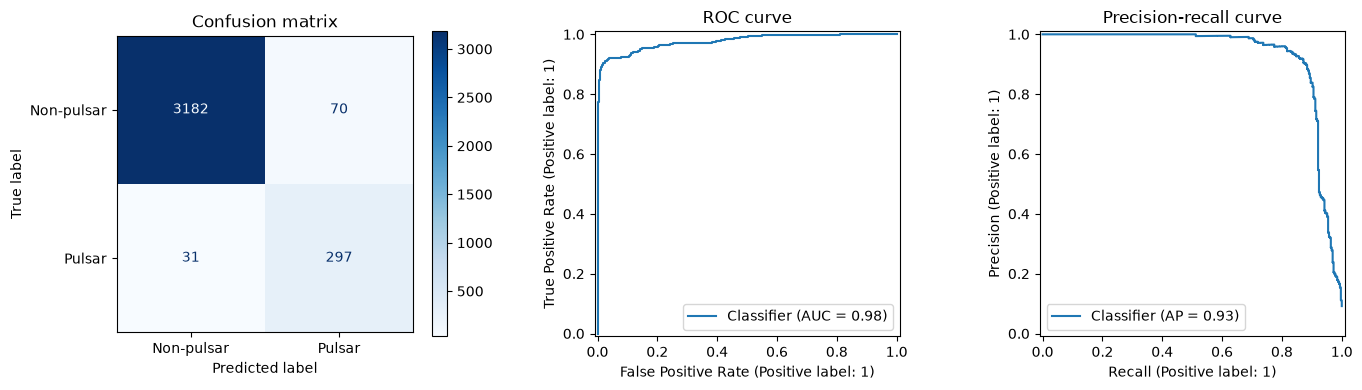

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Non-pulsar','Pulsar'], cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion matrix')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title('ROC curve')

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2])
axes[2].set_title('Precision-recall curve')

plt.tight_layout()
plt.savefig('../reports/evaluation.png')
plt.show()

### SHAP: global feature importance (bar + beeswarm, both classes)

Using  shap.TreeExplainer to compute SHAP values for every test-set prediction. Results are visualised using both a bar plot (showing mean absolute feature importance) and a beeswarm plot (showing the distribution of SHAP values across samples) which reveals how feature values influence predictions. This is done separately for both classes: pulsar and non-pulsar.

SHAP values are structured as (n_samples, n_features) for this XGBoost model. For binary classification, SHAP values for the non-pulsar class are the negative of the pulsar class values, so the sign is flipped when plotting the non-pulsar class for intuitive interpretation (red = high feature value pushing toward non-pulsar, blue = low feature value pushing toward non-pulsar).

SHAP is computed on X_test only (after scaling, but not SMOTE-transformed), since SMOTE is strictly a training-time operation and should not influence interpretability of real-world predictions. Evaluating on test data ensures explanations reflect genuine generalisation behaviour rather than training-set memorisation.

The consistent directional relationships across features confirm the model is using physically meaningful patterns rather than spurious correlations. 

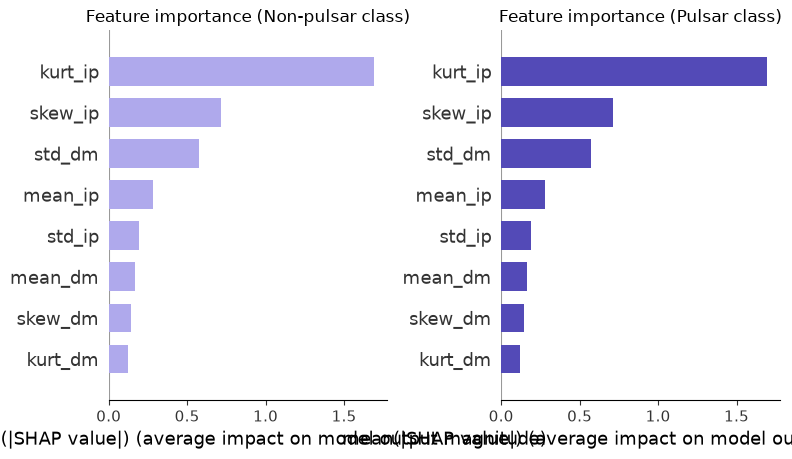

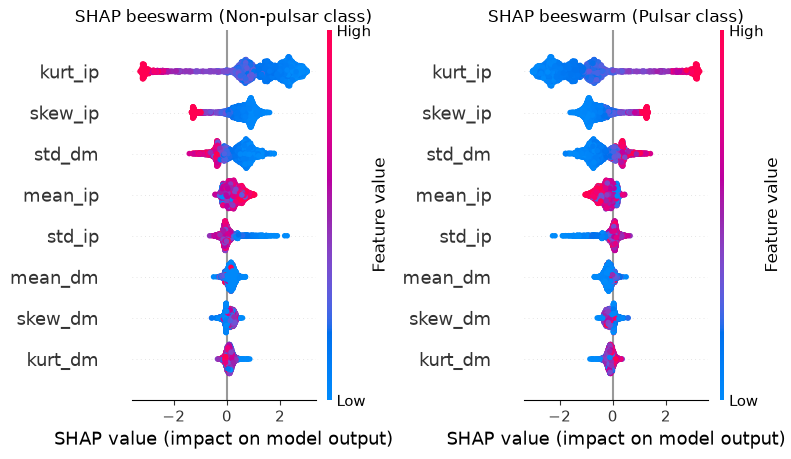

In [19]:
import shap
# Get the XGBoost classifier from the pipeline
xgb_clf = best_model.named_steps['clf']

# Transform X_test through scaler only (SMOTE is training only)
scaler = best_model.named_steps['scaler']
X_test_scaled = scaler.transform(X_test)

explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test_scaled)

feature_names = X.columns.tolist()

# Bar plots: mean, SHAP value, per feature, one per class 
fig, axes = plt.subplots(1, 2, figsize=(25, 6)) 
# Non-pulsar class (negative SHAP values)
plt.sca(axes[0])
shap.summary_plot(-shap_values, X_test_scaled, feature_names=feature_names,
                   plot_type='bar', show=False, color='#AFA9EC')
axes[0].set_title('Feature importance (Non-pulsar class)')

# Pulsar class (positive SHAP values)
plt.sca(axes[1])
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names,
                   plot_type='bar', show=False, color='#534AB7')
axes[1].set_title('Feature importance (Pulsar class)')

plt.tight_layout()
plt.savefig('../reports/shap_summary_bar_both_classes.png', bbox_inches='tight')
plt.show()

# Beeswarm plots
fig, axes = plt.subplots(1, 2, figsize=(30, 6))

# Non-pulsar class (negative SHAP values)
plt.sca(axes[0])
shap.summary_plot(-shap_values, X_test_scaled, feature_names=feature_names, show=False)
axes[0].set_title('SHAP beeswarm (Non-pulsar class)')

# Pulsar class (positive SHAP values)
plt.sca(axes[1])
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, show=False)
axes[1].set_title('SHAP beeswarm (Pulsar class)')

plt.tight_layout()
plt.savefig('../reports/shap_beeswarm_both_classes.png', bbox_inches='tight')
plt.show()

### Printing underlying SHAP numbers
Table showing the mean absolute SHAP value for each feature across the test set,
sorted by importance for the pulsar class.

In [24]:
shap_importance = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap_pulsar': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap_pulsar', ascending=False).reset_index(drop=True)

print("Mean | SHAP value :")
print(shap_importance.round(4).to_string(index=False))

Mean | SHAP value :
feature  mean_abs_shap_pulsar
kurt_ip                1.6922
skew_ip                0.7143
 std_dm                0.5726
mean_ip                0.2821
 std_ip                0.1910
mean_dm                0.1666
skew_dm                0.1434
kurt_dm                0.1213


### SHAP force plots: pulsar class

Generates 2 SHAP force plots for the pulsar class: one for the most confidently correct pulsar prediction and one for the most borderline case (probability closest to 0.5).

Global SHAP summaries show which features matter on average, but they do not explain individual predictions. Force plots provide local interpretability by showing how each feature pushes a specific prediction toward or away from the pulsar class. Comparing a highly confident prediction with a borderline one makes the model’s behaviour near the decision boundary more interpretable, which is where misclassifications are most likely to occur.

The force plots demonstrate that the model's decisions are interpretable and consistent, with the same features driving predictions regardless of the predicted class

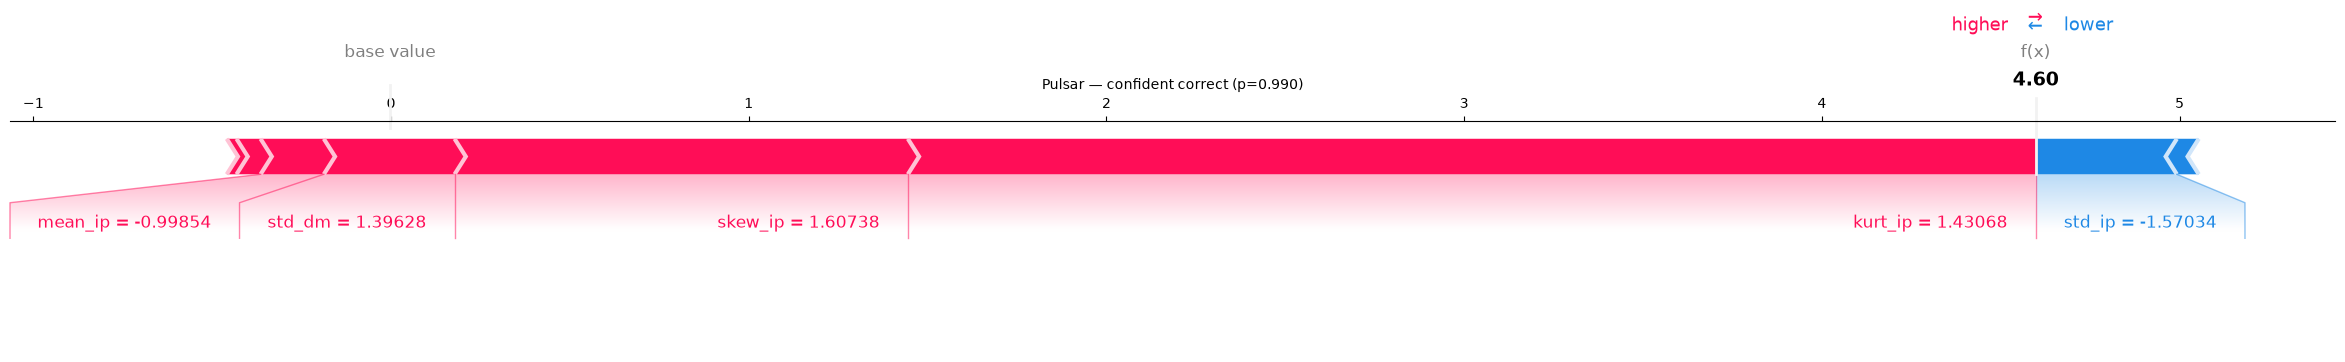

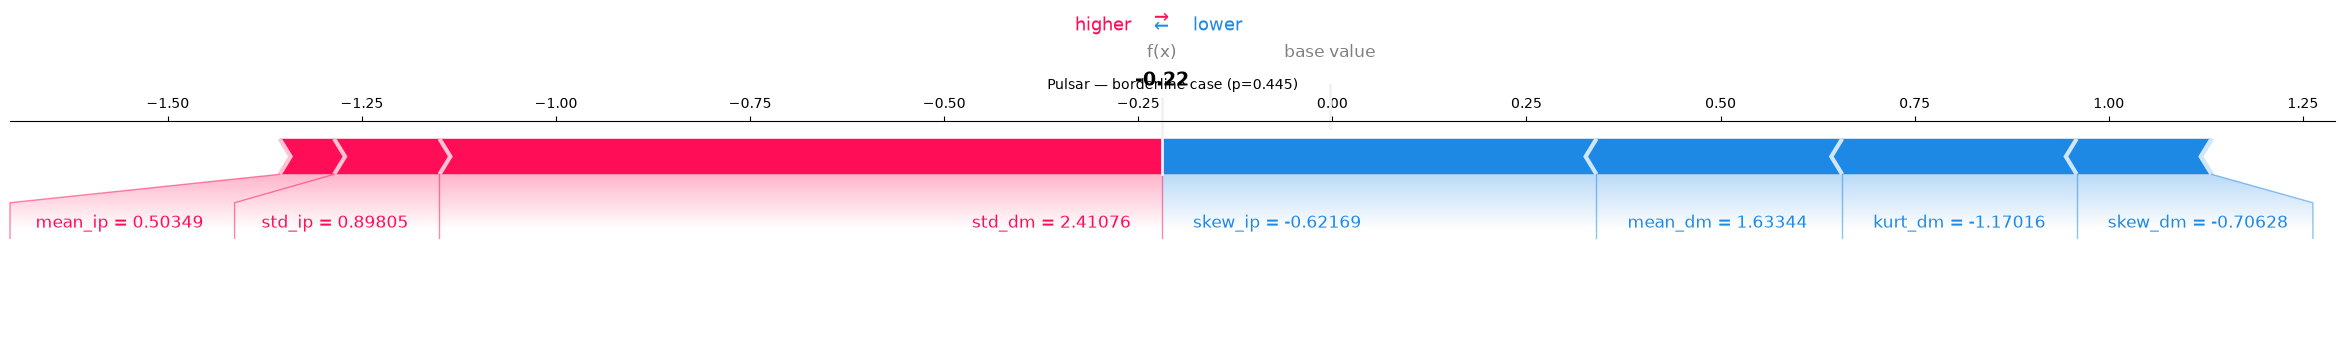

In [25]:
def plot_force(idx_in_test, class_idx, label, fname):
    rounded_features = np.round(X_test_scaled[idx_in_test], 5)

    shap_values_to_plot = shap_values[idx_in_test] if class_idx == 1 else -shap_values[idx_in_test]
    
    expected_value = explainer.expected_value
    
    shap.force_plot(
        expected_value,
        shap_values_to_plot,
        rounded_features,
        feature_names=feature_names,
        matplotlib=True, 
        show=False, 
        figsize=(30, 3)
    )
    plt.title(label, fontsize=10)
    plt.savefig(f'../reports/{fname}', dpi=150, bbox_inches='tight')
    plt.show()

# Pulsar examples: most confident correct prediction and the most borderline one
pulsar_test_idx = np.where(y_test.values == 1)[0]
pulsar_proba = y_proba[pulsar_test_idx]

confident_pulsar_i = pulsar_test_idx[np.argmax(pulsar_proba)]
borderline_pulsar_i = pulsar_test_idx[np.argmin(np.abs(pulsar_proba - 0.5))]

plot_force(confident_pulsar_i, 1,
           f'Pulsar — confident correct (p={y_proba[confident_pulsar_i]:.3f})',
           'shap_force_pulsar_confident.png')

plot_force(borderline_pulsar_i, 1,
           f'Pulsar — borderline case (p={y_proba[borderline_pulsar_i]:.3f})',
           'shap_force_pulsar_borderline.png')

### SHAP force plots: non-pulsar class

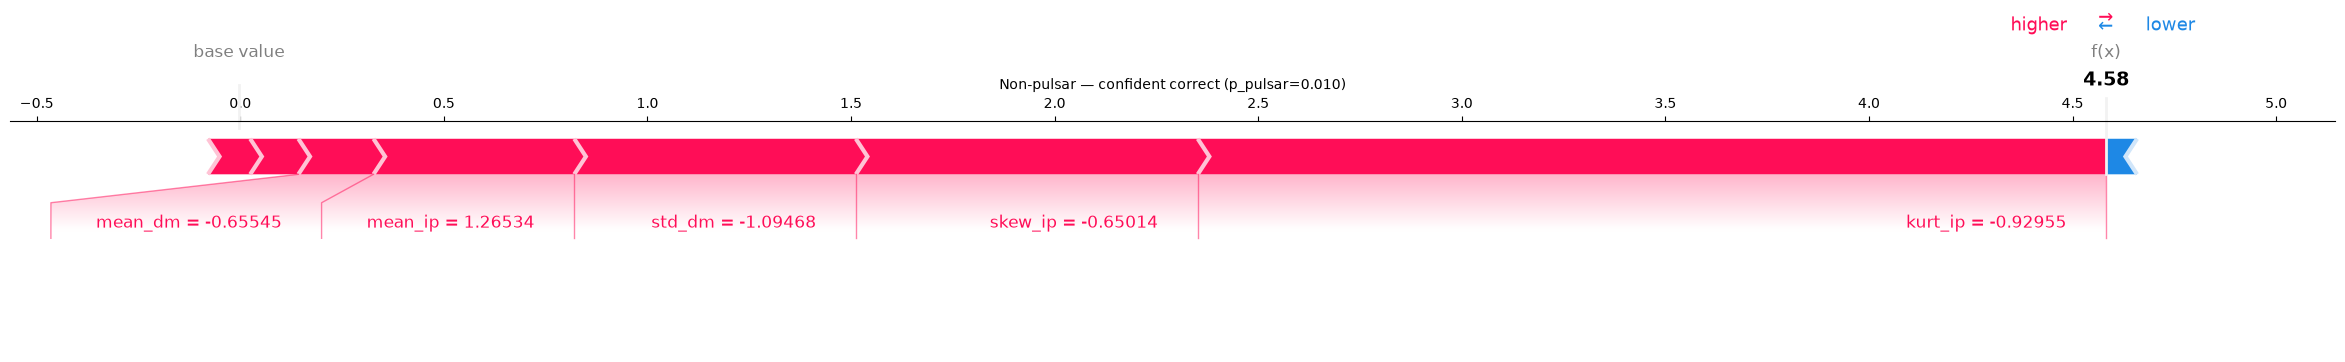

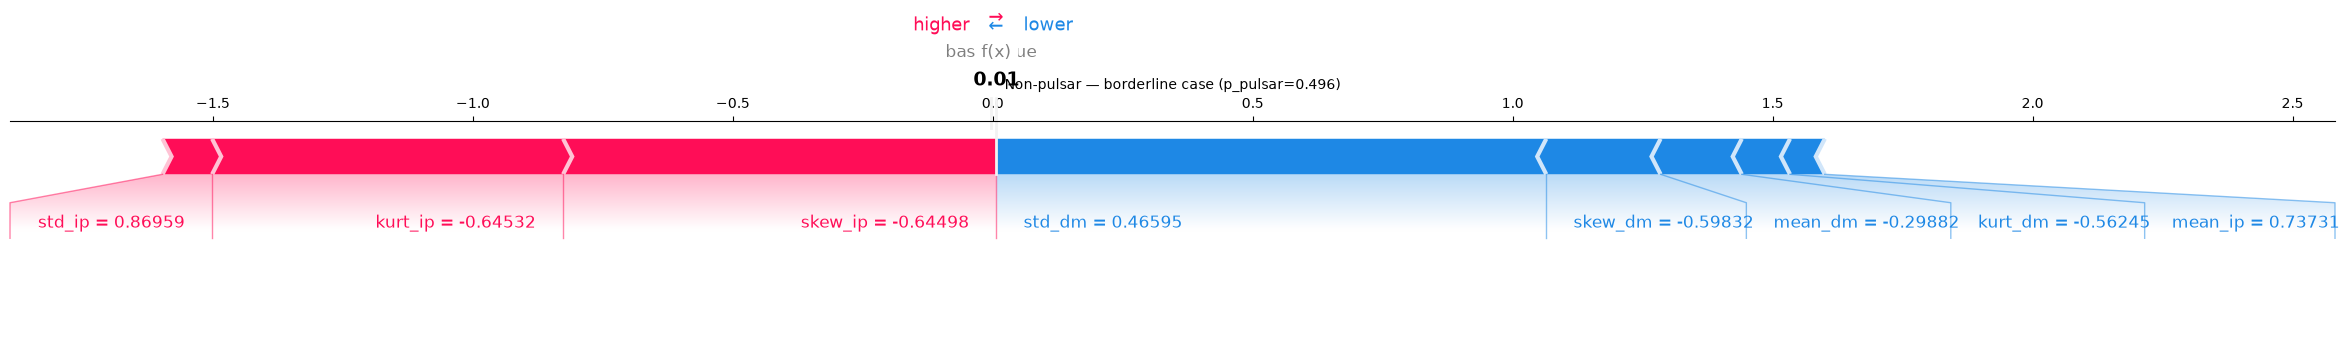

In [26]:
# Same for the non-pulsar class
nonpulsar_test_idx = np.where(y_test.values == 0)[0]
nonpulsar_proba = y_proba[nonpulsar_test_idx]  # P(pulsar); low = confidently non-pulsar

confident_nonpulsar_i = nonpulsar_test_idx[np.argmin(nonpulsar_proba)]
borderline_nonpulsar_i = nonpulsar_test_idx[np.argmin(np.abs(nonpulsar_proba - 0.5))]

plot_force(confident_nonpulsar_i, 0,
           f'Non-pulsar — confident correct (p_pulsar={y_proba[confident_nonpulsar_i]:.3f})',
           'shap_force_nonpulsar_confident.png')

plot_force(borderline_nonpulsar_i, 0,
           f'Non-pulsar — borderline case (p_pulsar={y_proba[borderline_nonpulsar_i]:.3f})',
           'shap_force_nonpulsar_borderline.png')

### Saving the model
#### Model Type: XGBoost Classifier
- Selected over Random Forest for achieving better recall and F1-score on the test set, aligning with the project's primary objective.

#### Pulsar Class (Minority Class)
Recall: 0.905
Precision: 0.809
F1-Score: 0.855

#### Non-Pulsar Class (Majority Class)
Recall: 0.984
Precision: 0.985
F1-Score: 0.984

#### Overall Accuracy: 0.974
#### ROC-AUC: 0.977

#### Model Tuned Hyperparameters: 
- Row Sampling Rate (subsample): 0.8
- Class Weight Scaling (scale_pos_weight): 1
- Number of Trees (n_estimators):	400
- Maximum Tree Depth (max_depth): 9
- Learning Rate (learning_rate): 0.01
- Column Sampling Rate (colsample_bytree): 0.7

In [27]:
import joblib
joblib.dump(best_model, '../models/pulsar_pipeline.joblib')
print("Model saved.")

Model saved.
